# process attention pattern features

get rid of some nans, do some scaling, compute covariances, and then save a PCA

this relies on having run notebook 01

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import muutils.tensor_info
import numpy as np
import polars as pl
from jaxtyping import Float
from muutils.dbg import dbg_tensor
from sklearn.decomposition import PCA

# attention-motifs
from attn_embed.features.analysis import (
	aggregate_feature_stats,
	filter_data,
	normalize_data,
	null_stats,
	pca_importance_table,
	plot_importance_covariance,
)
from attn_embed.features.plotting import (
	apply_pca,
	plot_correlation_matrix,
	plot_embedding,
)

In [2]:
# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/features/")
PATH_FIGURES: Path = Path("figures/")

In [ ]:
# raw data from file instead of regenerating
# if you changed anything in notebook 01 or when generating activations, change this path!
DATA_RAW = pl.read_ndjson(PATH_BASE / "raw-m2-p16-c101.jsonl")

# basic data inspection

In [4]:
# display(DATA_RAW)
# display(set(DATA_RAW.dtypes))	
# display(DATA_RAW.head())
# display(DATA_RAW.describe())
# print(f"{DATA_RAW['activation.model'].unique() = }")
# for col in DATA_RAW.columns:
# 	if col.startswith("activation"):
# 		print(f"{col = }")
display(null_stats(DATA_RAW))

feature,missing_count,missing_frac
str,i64,f64
"""feat.gram.col.hist.mean""",0,0.0
"""feat.gram.col.hist.entropy""",0,0.0
"""feat.gram.skew.hist.linreg.slo…",0,0.0
"""feat.log.gram.skew.hist.mean""",0,0.0
"""feat.log.gram.col.hist.linreg.…",0,0.0
…,…,…
"""feat.gram.row.hist.mean""",0,0.0
"""feat.diag.linreg.slope""",0,0.0
"""feat.diag.mean""",0,0.0


# filter nans and certain models

In [5]:
# this will filter all-nan rows
DATA_FILTERED: pl.DataFrame = filter_data(
	DATA_RAW,
	# tinystories and small pythia models look very different in embedding space, so we get rid of them
	remove_models=["tiny-stories-1M", "pythia-14m"],
)
null_stats(DATA_FILTERED)

Removing 2 models: ['tiny-stories-1M', 'pythia-14m']
Removed 0/4352 rows
Removing 2/94 feat.* columns due to zero variance or excessive missing values
feat.log.gram.col.hist.median                                μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=4352 dtype=float64
feat.log.gram.row.hist.median                                μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=4352 dtype=float64


feature,missing_count,missing_frac
str,i64,f64
"""feat.gram.col.hist.mean""",0,0.0
"""feat.gram.col.hist.entropy""",0,0.0
"""feat.gram.skew.hist.linreg.slo…",0,0.0
"""feat.log.gram.skew.hist.mean""",0,0.0
"""feat.log.gram.col.hist.linreg.…",0,0.0
…,…,…
"""feat.gram.row.hist.mean""",0,0.0
"""feat.diag.linreg.slope""",0,0.0
"""feat.diag.mean""",0,0.0


# scaling

In [6]:
FEATURE_COLS: list[str] = [
	col for col in DATA_FILTERED.columns if col.startswith("feat.")
]
DATA_SCALED: pl.DataFrame
_data_norms: pl.DataFrame
DATA_SCALED, _data_norms = normalize_data(DATA_FILTERED, FEATURE_COLS)
_data_norms.write_ndjson(PATH_BASE / "norms.jsonl")
DATA_SCALED.write_ndjson(PATH_BASE / "scaled.jsonl")
display(null_stats(DATA_SCALED))
META_COLS: list[str] = [
	col for col in DATA_SCALED.columns if col.startswith("activation.")
]

feature,missing_count,missing_frac
str,i64,f64
"""feat.gram.col.hist.mean""",0,0.0
"""feat.gram.col.hist.entropy""",0,0.0
"""feat.gram.skew.hist.linreg.slo…",0,0.0
"""feat.log.gram.skew.hist.mean""",0,0.0
"""feat.log.gram.col.hist.linreg.…",0,0.0
…,…,…
"""feat.gram.row.hist.mean""",0,0.0
"""feat.diag.linreg.slope""",0,0.0
"""feat.diag.mean""",0,0.0


[ ~/attn-motifs-anon/attn_embed/attn_embed/features/plotting.py:35 ] corr_mat: μ=0.01 σ=0.42 x̃=-0.01 R=[-1.00,1.00] ℙ=|▁▂▄█▄▂▁| shape=(92,92) dtype=float64


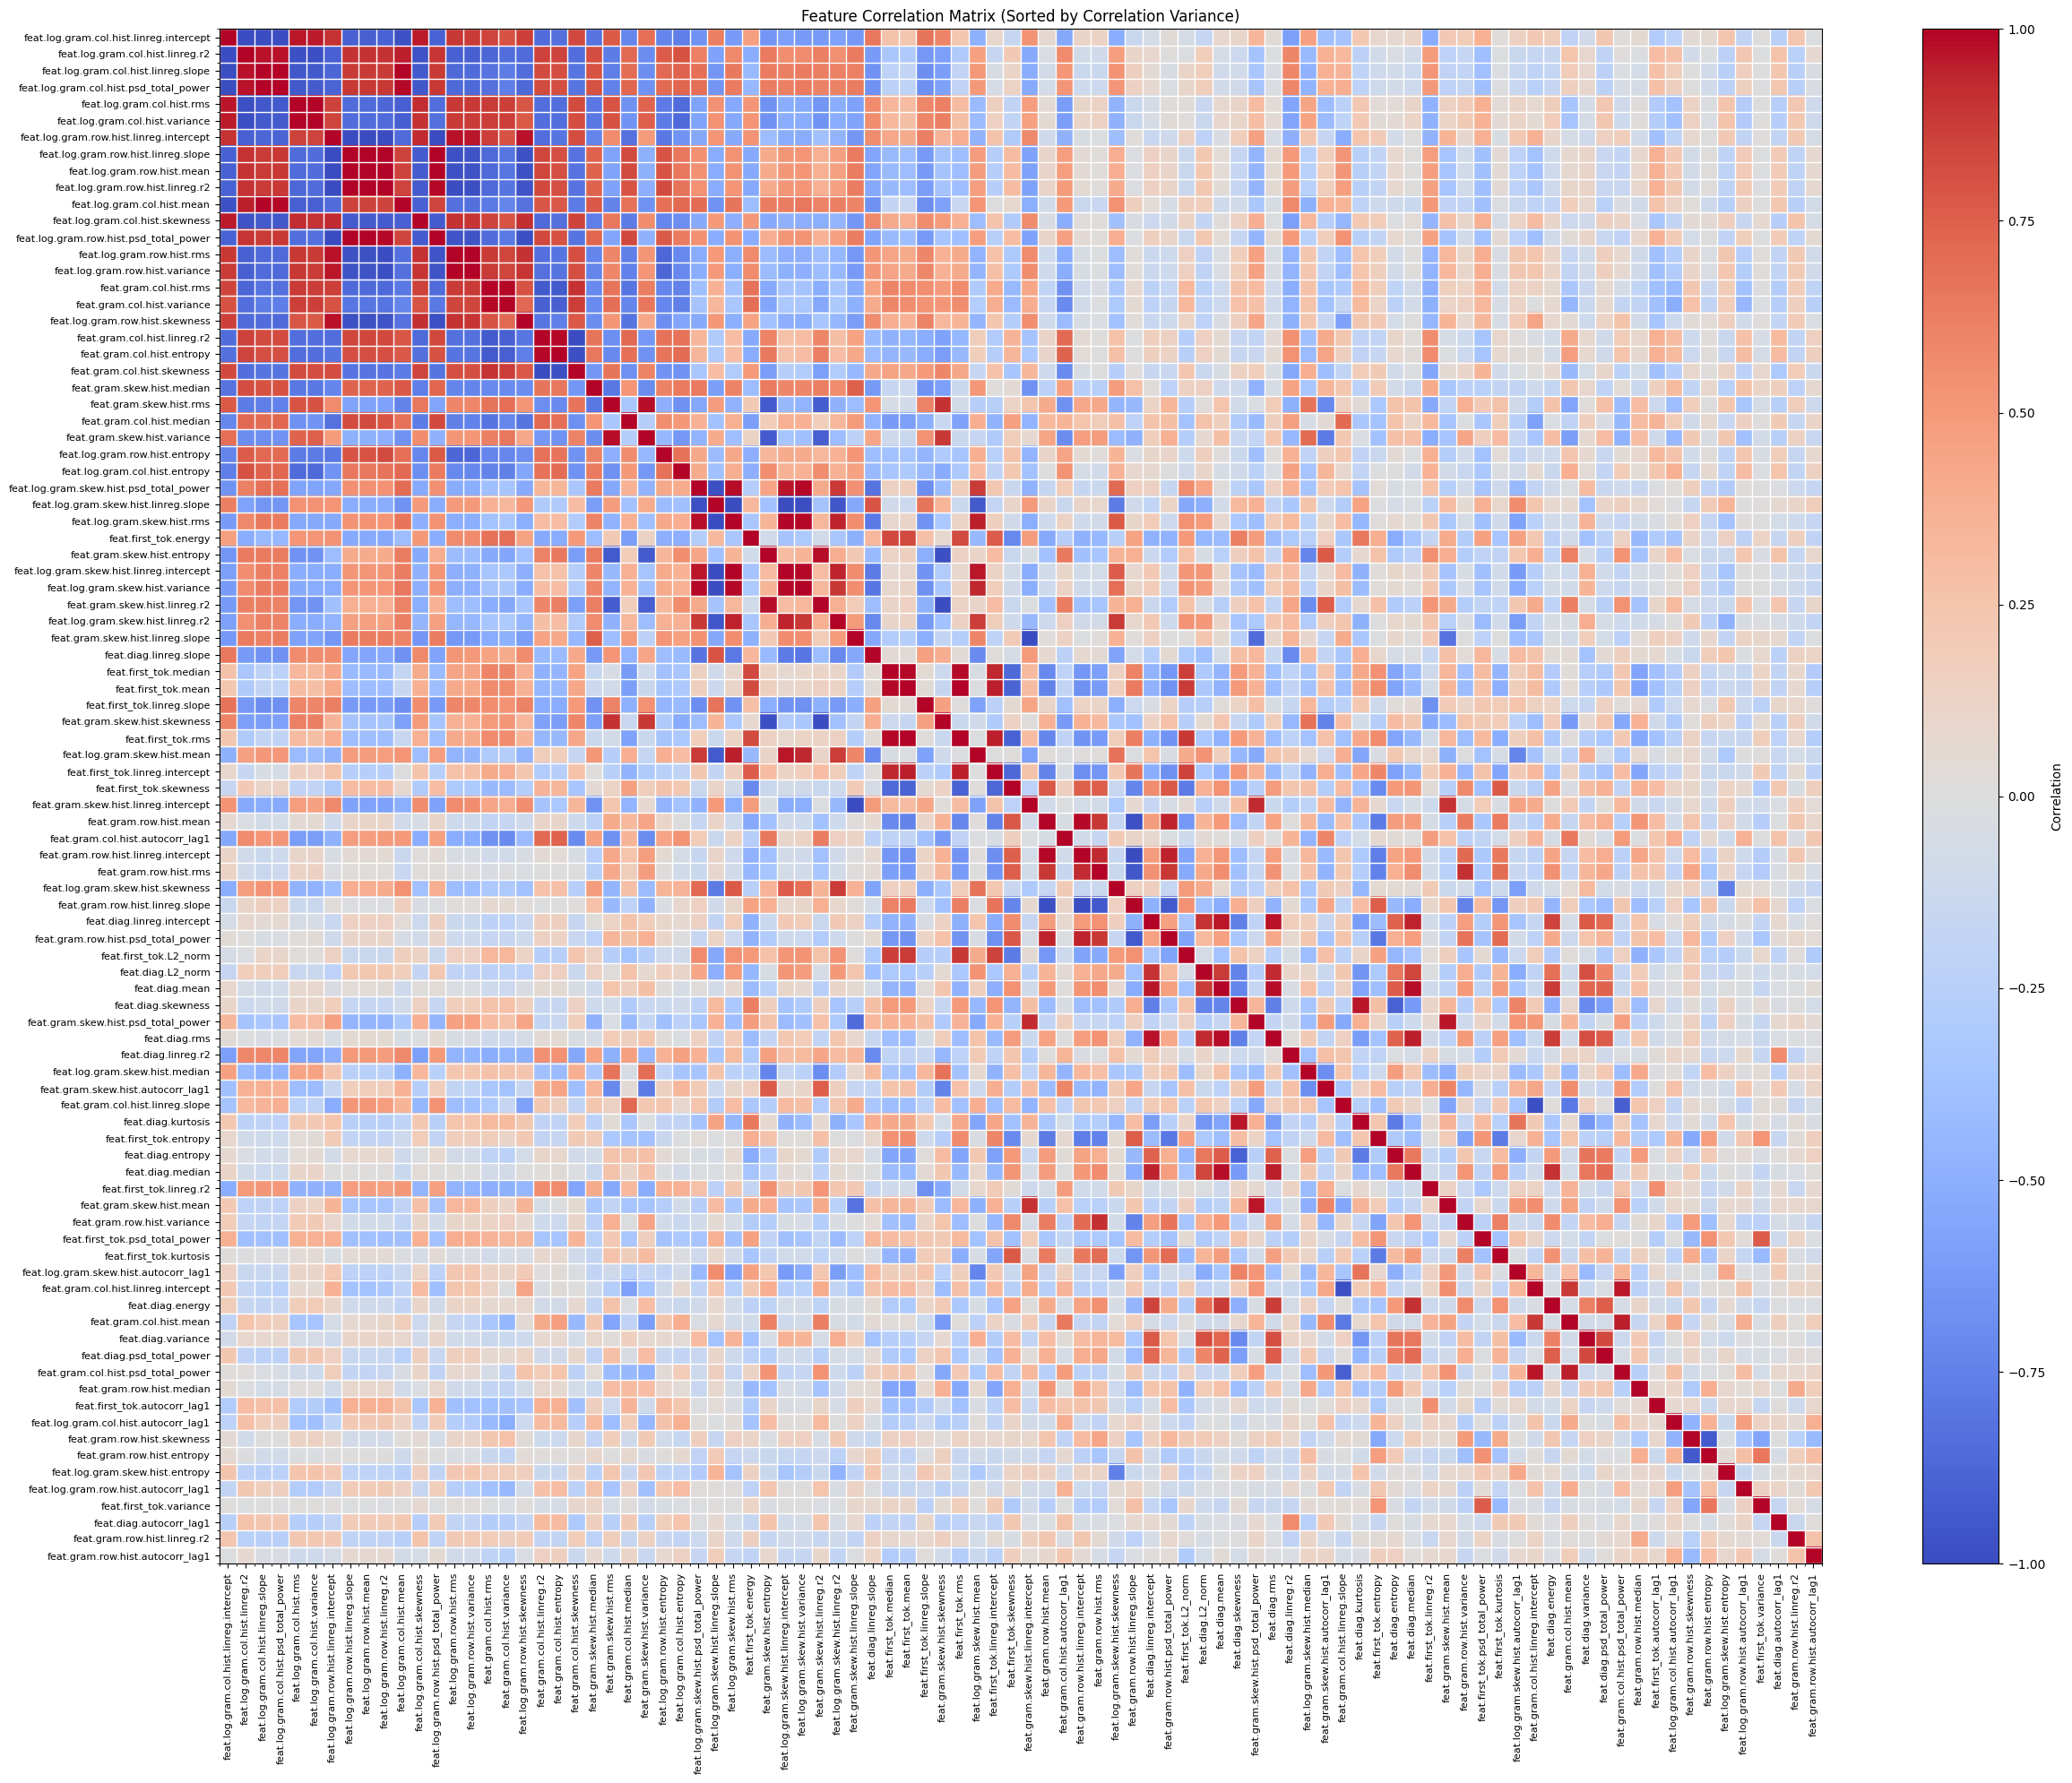

In [7]:
plot_correlation_matrix(
	DATA_SCALED,
	FEATURE_COLS,
	sort_by="var",
)

# PCA

~/attn-motifs-anon/attn_embed/attn_embed/features/plotting.py:153: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


Number of components: 16
Total explained variance: 0.9305
Components needed for 80% variance: 7
Components needed for 90% variance: 13


[ <ipykernel>:6 ] PCA_DATA: μ=-0.00 σ=2.31 x̃=-0.04 R=[-10.47,21.74] ℙ=| ▂█    | shape=(4352,16) dtype=float64
[ <ipykernel>:7 ] PCA_OBJ.components_: μ=0.01 σ=0.10 x̃=0.00 R=[-0.34,0.60] ℙ=| ▃█▂   | shape=(16,92) dtype=float64


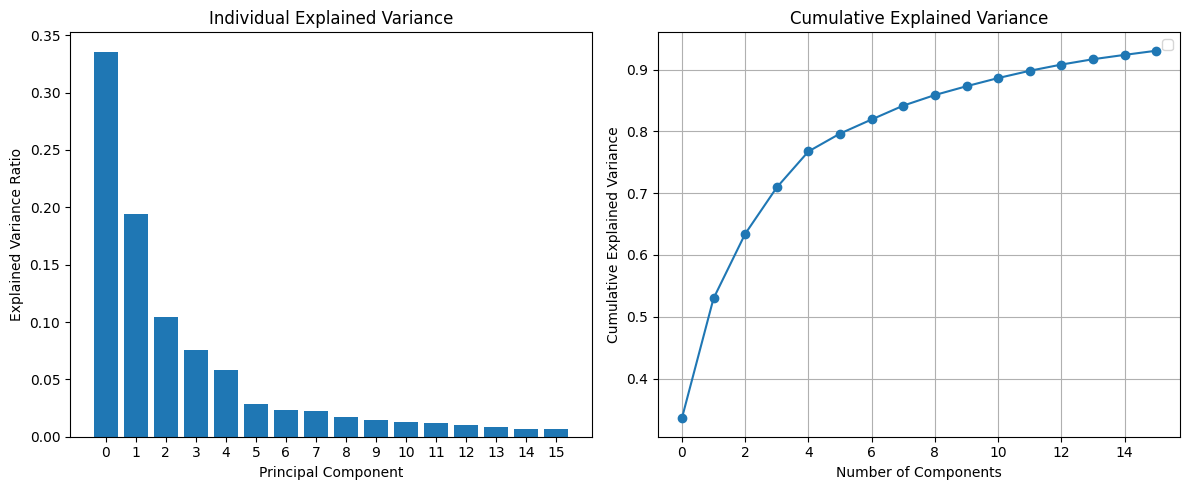

In [8]:
# dbg_tensor(DATA_SCALED[FEATURE_COLS].to_numpy())
PCA_DATA: np.ndarray
PCA_OBJ: PCA
PCA_DATA, PCA_OBJ = apply_pca(DATA_SCALED, n_components=16, feature_cols=FEATURE_COLS)
plt.savefig(PATH_FIGURES / "pca-variance.pdf", bbox_inches="tight", pad_inches=0.01)
dbg_tensor(PCA_DATA)
dbg_tensor(PCA_OBJ.components_)

# pca and meta in one dataframe
DF_PCA: pl.DataFrame = pl.concat(
	[
		# metadata -- "activation.*"
		DATA_SCALED[META_COLS],
		# pca cols
		pl.DataFrame(PCA_DATA, schema=[f"pc.{i}" for i in range(PCA_DATA.shape[1])]),
	],
	how="horizontal",
)
DF_PCA.write_ndjson(PATH_BASE / "pca.jsonl")

In [9]:
df_importance: pl.DataFrame = pca_importance_table(
	PCA_OBJ,
	feature_names=FEATURE_COLS,
)
df_importance.sort(pl.col("PC0").abs(), descending=True)

feature,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,abs_mean,abs_max,abs_var,var_weighted
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""feat.log.gram.col.hist.linreg.…",0.173601,-0.028807,-0.028771,-0.020391,-0.020909,0.027452,0.004833,0.025184,0.022059,-0.030162,0.010445,0.018516,0.027364,-0.108732,0.045081,0.078317,0.041914,0.173601,0.001784,0.074315
"""feat.log.gram.col.hist.linreg.…",-0.173165,0.037286,0.00772,0.019198,0.042714,-0.048406,-0.007632,0.001167,-0.033576,0.027381,-0.001893,0.006748,-0.003631,0.081227,-0.035289,-0.0732,0.037515,0.173165,0.001791,0.074253
"""feat.log.gram.col.hist.psd_tot…",0.171002,-0.036826,0.008231,-0.02112,-0.059539,0.060624,0.004516,-0.009225,0.03973,-0.02412,0.005919,-0.039241,-0.004714,-0.067842,0.036227,0.08103,0.041869,0.171002,0.001664,0.075527
"""feat.log.gram.col.hist.linreg.…",0.170756,-0.041894,0.007445,-0.015208,-0.056231,0.048786,0.004928,-0.007537,0.03826,-0.03628,0.002801,-0.038876,0.005873,-0.07408,0.056875,0.091928,0.04361,0.170756,0.001744,0.075723
"""feat.log.gram.col.hist.rms""",-0.169073,0.037826,0.04842,0.003562,-0.003053,0.01333,-0.022631,-0.03602,0.001149,0.058687,0.004694,-0.046026,-0.072229,0.128863,-0.09924,-0.095553,0.052522,0.169073,0.002289,0.075949
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feat.diag.median""",0.005266,0.167574,0.018086,0.188804,0.067542,0.165391,-0.157537,-0.024785,-0.068855,0.011945,0.046664,0.156554,0.032815,0.004664,0.156753,-0.08833,0.085098,0.188804,0.004413,0.069099
"""feat.gram.row.hist.entropy""",-0.005039,-0.014082,-0.051545,-0.146997,0.343969,0.034279,0.019656,-0.070707,0.145488,-0.085761,-0.062887,-0.03459,0.046058,-0.060722,0.168705,-0.121959,0.088278,0.343969,0.006718,0.051854
"""feat.gram.row.hist.linreg.slop…",0.003447,-0.196241,0.048044,-0.044375,0.119922,0.181209,0.033235,0.080018,-0.16804,0.098648,0.017214,-0.051895,0.032554,-0.038651,0.094566,-0.023714,0.076986,0.196241,0.003482,0.068947


In [10]:
display(aggregate_feature_stats(df_importance, side=1).sort("max", descending=True))

token,mean,min,max,median
str,f64,f64,f64,f64
"""gram""",0.081132,0.03852,0.14561,0.076731
"""diag""",0.088633,0.069626,0.143315,0.084536
"""log""",0.068392,0.037515,0.138705,0.061092
"""first_tok""",0.084835,0.052958,0.133031,0.071604


~/attn-motifs-anon/attn_embed/attn_embed/features/analysis.py:435: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
~/attn-motifs-anon/attn_embed/attn_embed/features/analysis.py:435: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


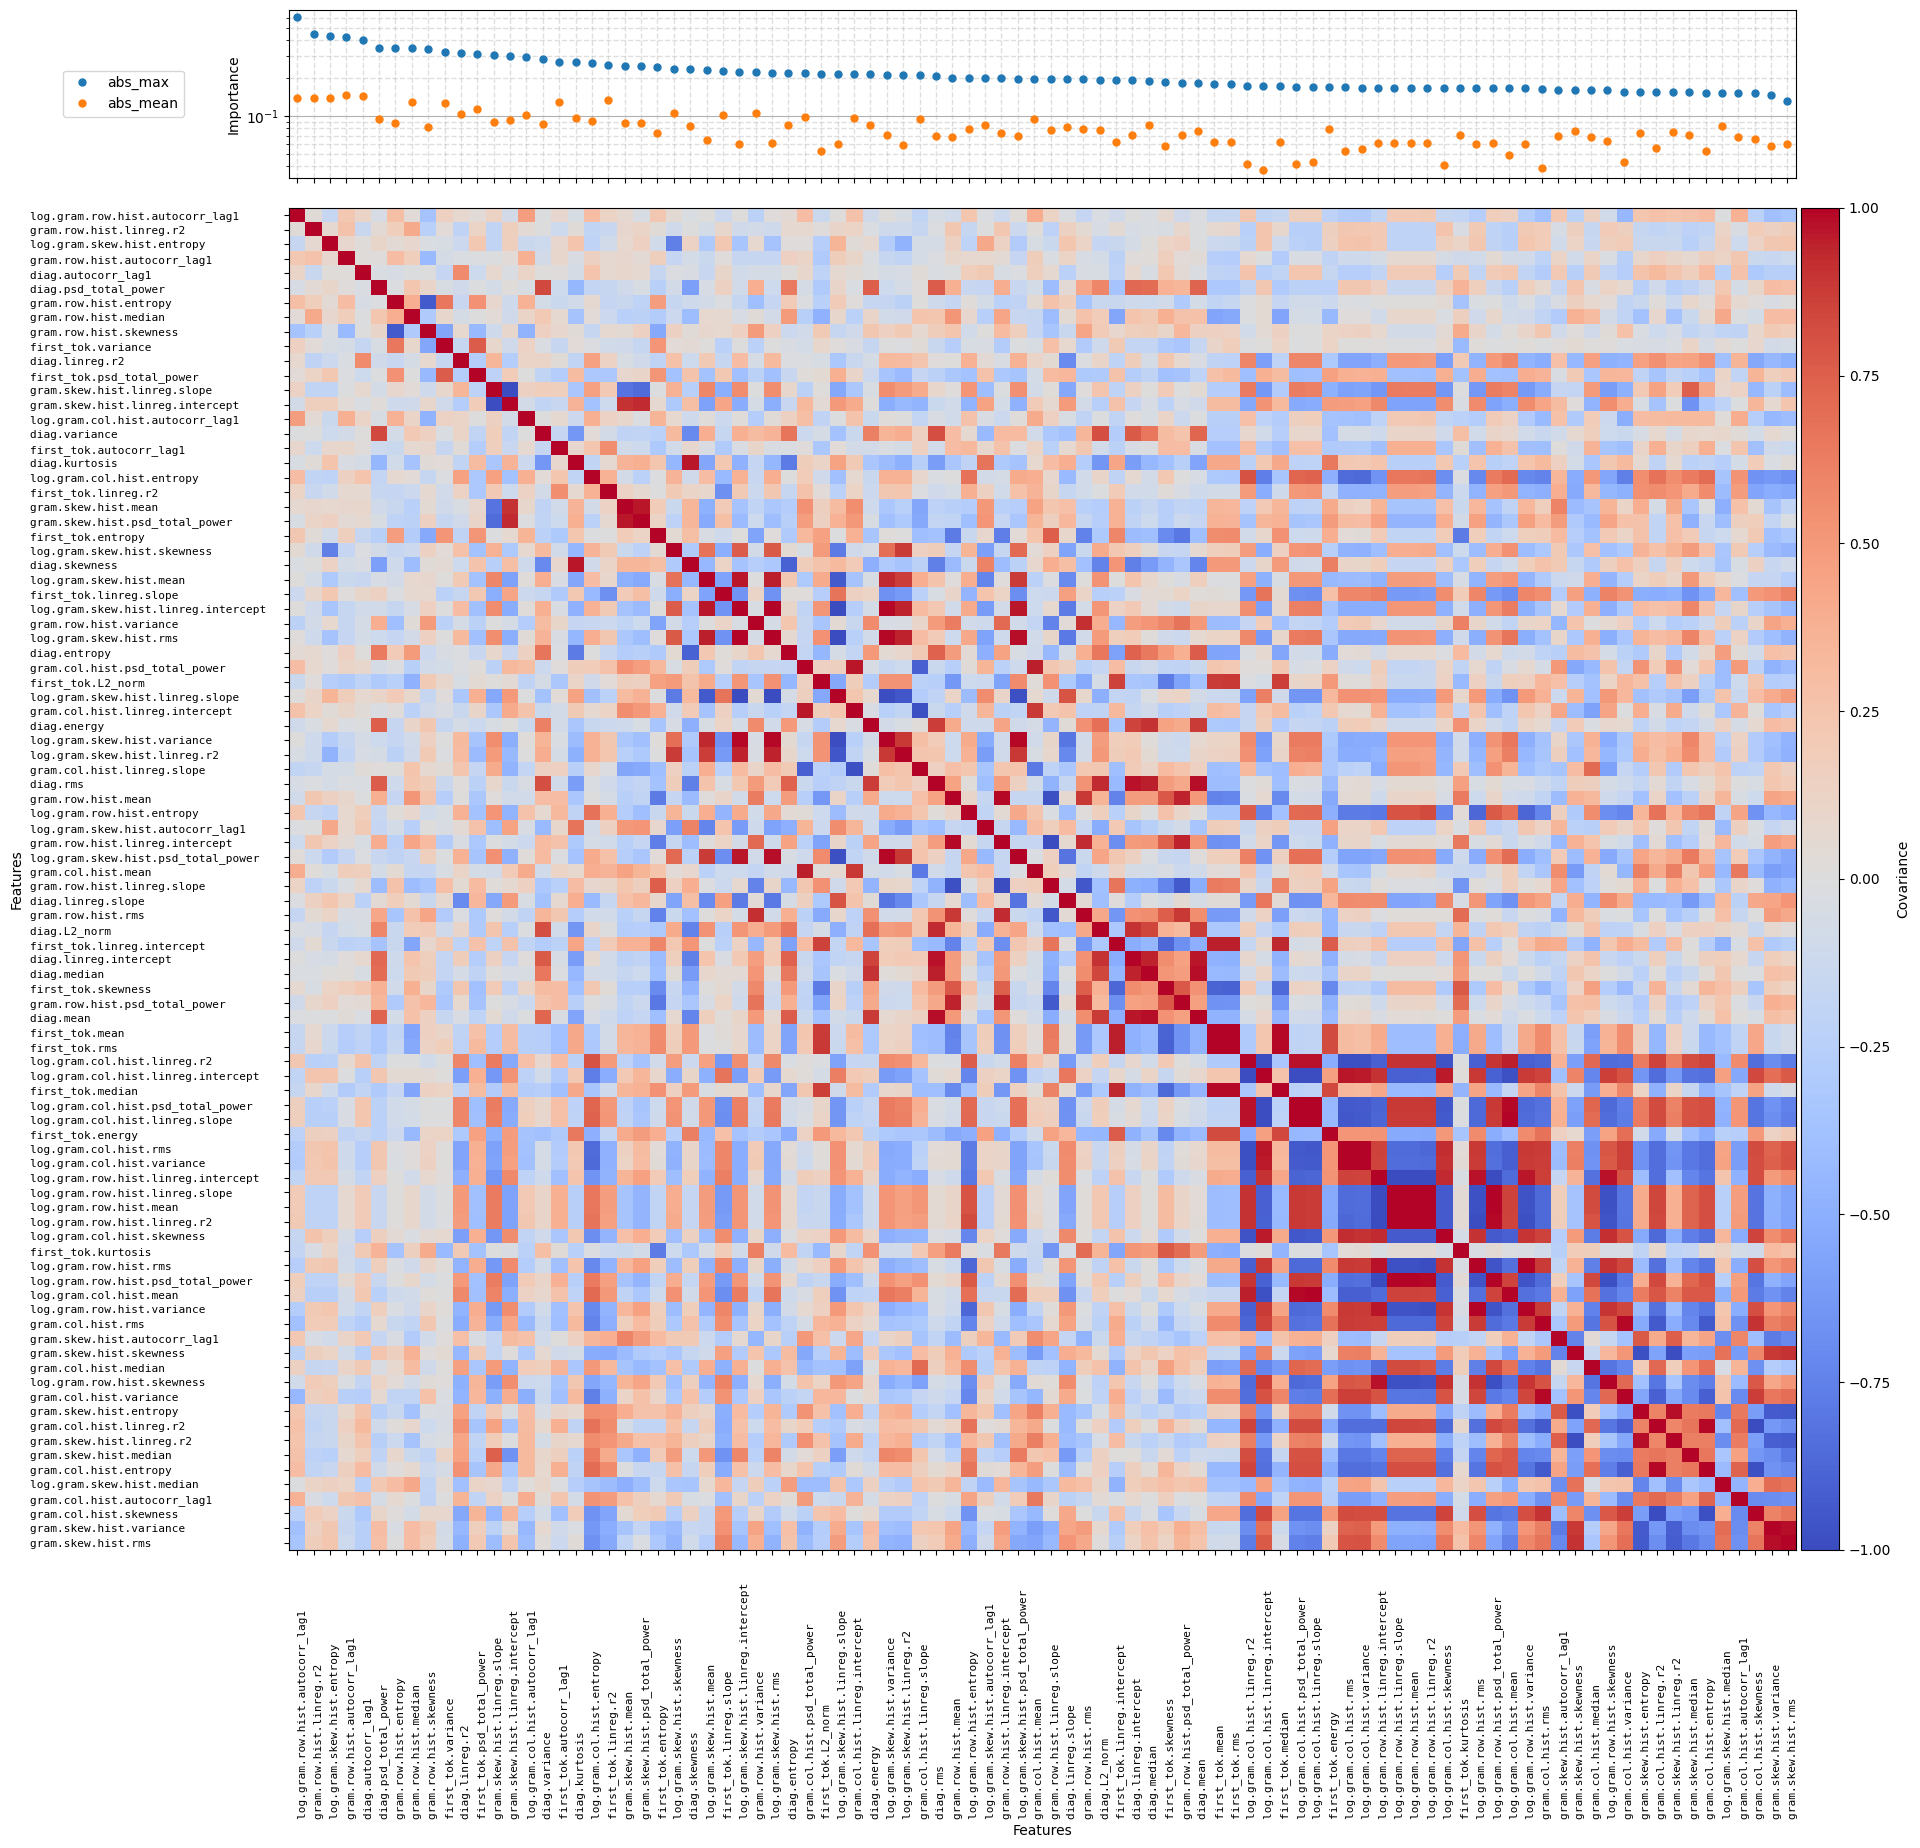

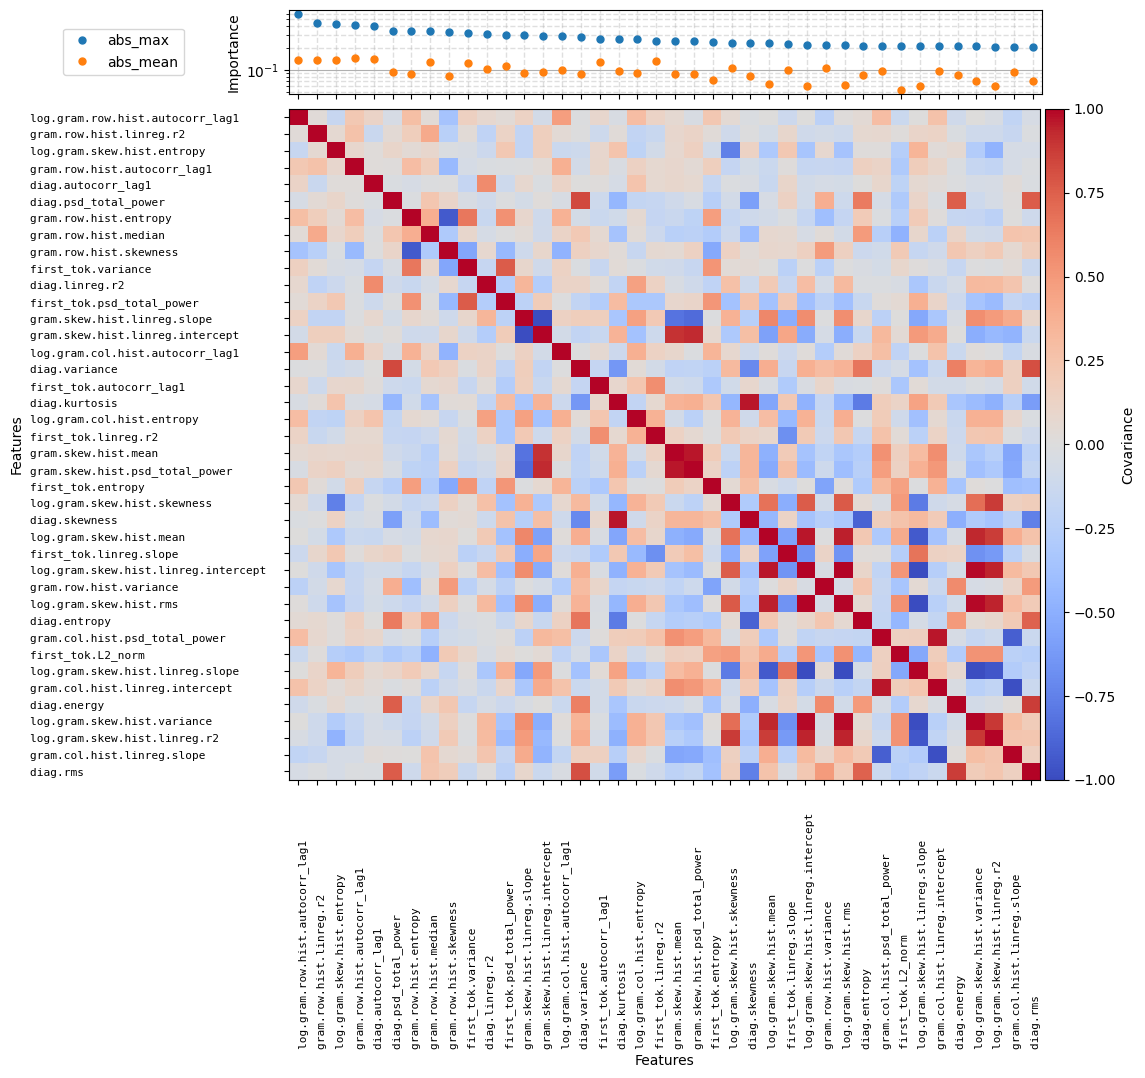

In [11]:
COV_FEATS: list[str]
COV_MAT: Float[np.ndarray, "n_features n_features"]

# full
COV_FEATS, COV_MAT = plot_importance_covariance(
	DATA_SCALED,
	df_importance,
	# feature_order=sorted(FEATURE_COLS, key=lambda x: x.split(".")[-1]),
	metrics=["abs_max", "abs_mean"],
	descending=True,
	cmap="coolwarm",
	figsize=(20, 20),
	tick_pad=100,
	imp_legend_align=-0.15,
)
plt.savefig(PATH_FIGURES / "feature-cov-full.pdf", bbox_inches="tight", pad_inches=0.01)

# reduced
plot_importance_covariance(
	DATA_SCALED,
	df_importance,
	# feature_order=sorted(FEATURE_COLS, key=lambda x: x.split(".")[-1]),
	metrics=["abs_max", "abs_mean"],
	descending=True,
	cmap="coolwarm",
	figsize=(10, 10),
	tick_pad=100,
	importance_threshold=0.2,
)
plt.savefig(
	PATH_FIGURES / "feature-cov-reduced.pdf",
	bbox_inches="tight",
	pad_inches=0.01,
)

In [12]:
# from attn_embed.features.analysis import print_covariance_groups
# print_covariance_groups(
# 	cov_feats=COV_FEATS,
# 	cov_mat=COV_MAT,
# 	df_importance=df_importance,
# 	threshold=0.9,
# )

saving to figures/pca-all.png
saving to figures/pca-all.jpg


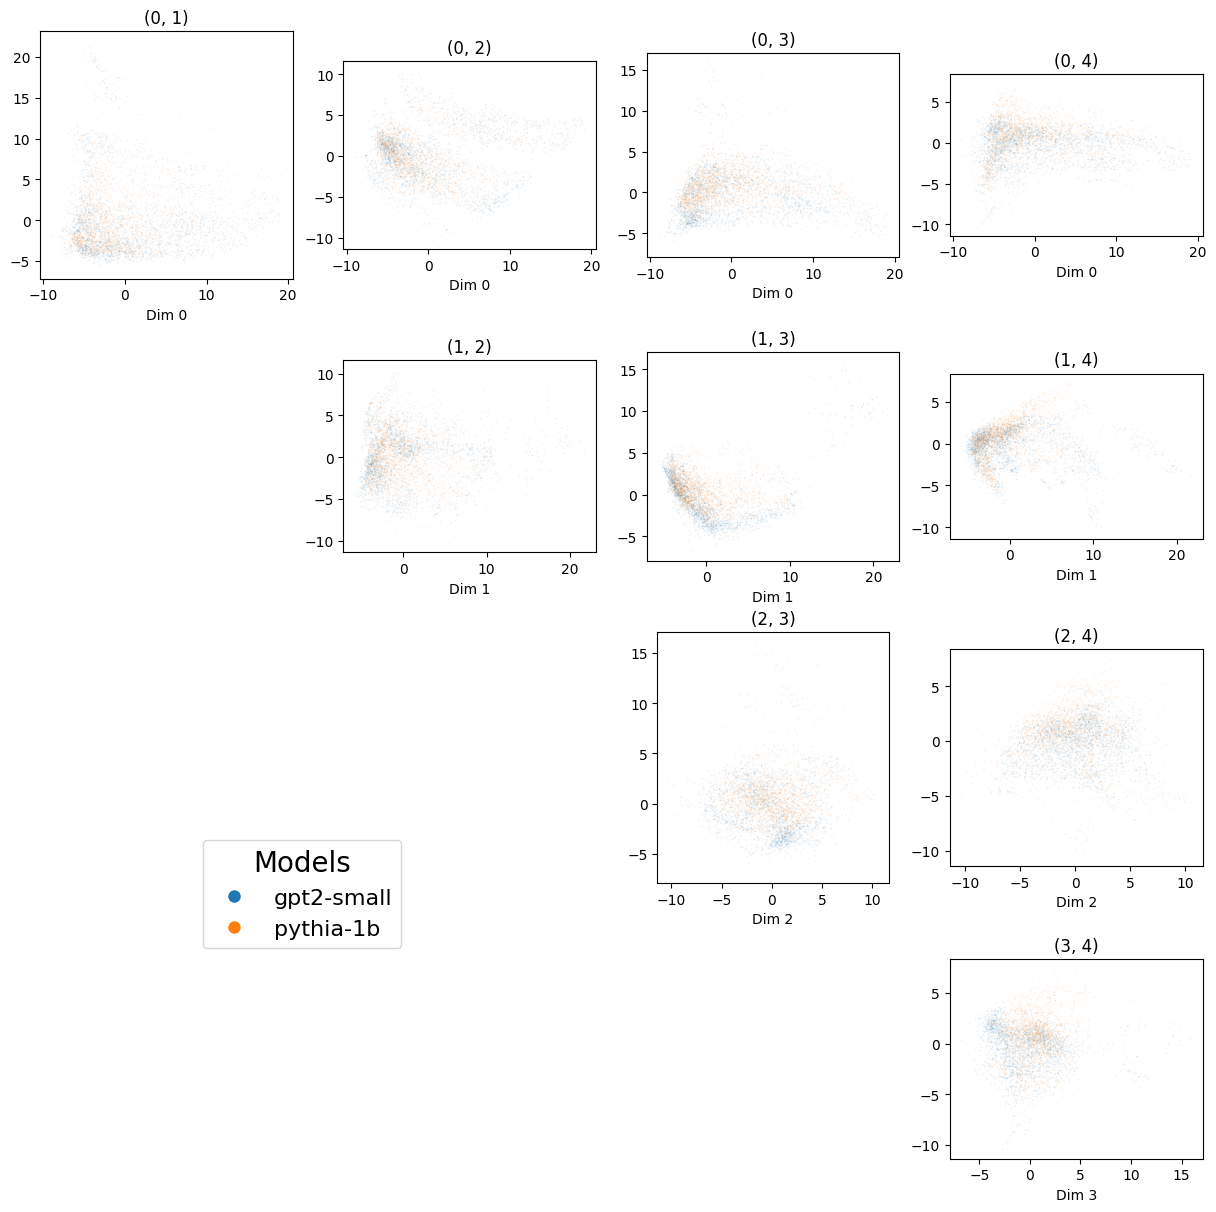

In [13]:
n_dims: int = 5
embed_fig, embed_ax = plt.subplots(
	n_dims - 1,
	n_dims - 1,
	figsize=(15, 15),
)
for i in range(n_dims - 1):
	for j in range(i + 1, n_dims):
		handles = plot_embedding(
			embedding=PCA_DATA,
			labels=DATA_SCALED["activation.model"],
			dims=(i, j),
			alpha=0.1,
			marker_size=1,
			title=f"({i}, {j})",
			ax=embed_ax[i, j - 1],
			do_legend=False,
		)
		embed_ax[i, j - 1].set_ylabel(None)

	for k in range(i):
		embed_ax[i, k].axis("off")

plt.legend(
	handles=handles,
	loc="lower left",
	bbox_to_anchor=(-3, 1),
	title="Models",
	fontsize=16,
	title_fontsize=20,
)
fig_pca_all_png: Path = PATH_FIGURES / "pca-all.png"
print(f"saving to {fig_pca_all_png}")
plt.savefig(fig_pca_all_png, dpi=250, bbox_inches="tight", pad_inches=0.01)
fig_pca_all_jpg: Path = PATH_FIGURES / "pca-all.jpg"
print(f"saving to {fig_pca_all_jpg}")
plt.savefig(fig_pca_all_jpg, bbox_inches="tight", pad_inches=0.01, dpi=500)

In [14]:
DATA_SCALED

feat.gram.col.hist.mean,feat.gram.col.hist.entropy,feat.gram.skew.hist.linreg.slope,feat.log.gram.skew.hist.mean,feat.log.gram.col.hist.linreg.slope,feat.diag.variance,feat.diag.energy,feat.gram.row.hist.autocorr_lag1,feat.gram.skew.hist.autocorr_lag1,feat.log.gram.col.hist.psd_total_power,activation.model,feat.log.gram.skew.hist.skewness,feat.log.gram.col.hist.skewness,feat.log.gram.skew.hist.entropy,feat.gram.skew.hist.linreg.r2,feat.diag.linreg.r2,feat.gram.row.hist.linreg.slope,feat.gram.skew.hist.skewness,feat.log.gram.row.hist.autocorr_lag1,feat.first_tok.variance,feat.log.gram.row.hist.linreg.intercept,feat.log.gram.skew.hist.median,feat.log.gram.row.hist.psd_total_power,feat.log.gram.col.hist.variance,feat.log.gram.skew.hist.autocorr_lag1,feat.first_tok.rms,feat.first_tok.entropy,feat.first_tok.autocorr_lag1,feat.gram.col.hist.linreg.intercept,feat.gram.col.hist.median,feat.diag.skewness,feat.gram.col.hist.psd_total_power,feat.log.gram.row.hist.skewness,feat.first_tok.median,feat.diag.rms,feat.log.gram.skew.hist.linreg.r2,activation.layer,…,feat.log.gram.col.hist.entropy,feat.gram.row.hist.rms,feat.gram.row.hist.skewness,feat.diag.psd_total_power,feat.diag.median,feat.first_tok.L2_norm,activation.head,feat.first_tok.energy,feat.gram.col.hist.rms,feat.gram.skew.hist.rms,activation.cache_key,feat.log.gram.row.hist.entropy,feat.diag.linreg.intercept,feat.gram.row.hist.linreg.r2,feat.gram.skew.hist.psd_total_power,feat.gram.row.hist.entropy,feat.gram.col.hist.linreg.r2,feat.gram.col.hist.variance,activation.cls,feat.gram.skew.hist.median,feat.log.gram.row.hist.linreg.r2,feat.log.gram.row.hist.rms,feat.gram.row.hist.median,feat.log.gram.col.hist.mean,feat.log.gram.col.hist.autocorr_lag1,feat.log.gram.col.hist.linreg.r2,feat.diag.autocorr_lag1,feat.gram.col.hist.autocorr_lag1,feat.log.gram.col.hist.rms,feat.log.gram.skew.hist.linreg.slope,feat.gram.col.hist.linreg.slope,feat.gram.skew.hist.variance,feat.gram.row.hist.mean,feat.diag.linreg.slope,feat.diag.mean,feat.gram.skew.hist.mean,feat.first_tok.linreg.r2
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,…,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-0.004338,2.214414,0.318005,-0.351606,1.891558,-0.28823,-0.225024,0.423186,0.882365,1.950401,"""gpt2-small""",0.454169,-2.417758,-0.373577,1.091693,0.353251,0.249222,-1.06047,0.076281,-0.214323,-2.347417,-0.751174,2.382469,-1.718058,0.364927,-1.214163,-0.679242,1.528444,-1.231981,1.313963,0.099888,-0.600792,-2.755817,-1.293817,-0.326291,0.301055,0,…,1.037184,0.022559,0.035991,-0.182951,-0.348801,-1.028996,0,-1.044722,-2.107159,-1.031573,"""blocks.0.attn.hook_pattern""",1.411162,-0.252362,-1.267792,-0.208094,-0.347582,2.749084,-1.788421,"""gpt2-small:L0:H0""",1.390445,2.393131,-2.159203,-0.477606,1.812508,0.105613,1.939545,0.125345,1.293258,-1.759985,0.061763,1.660863,-1.00586,0.123561,0.011526,-0.340161,0.228921,2.070891
-1.009465,-0.967352,0.204761,-0.398461,-1.113861,2.708833,6.764971,-1.184672,-1.178699,-1.045467,"""gpt2-small""",0.443088,0.665672,-0.373577,-1.345723,-0.510289,-3.424463,1.17833,-2.293381,-1.342256,0.736468,-0.788889,-0.699268,1.259403,0.518927,-1.8651,-2.86562,-2.361687,-0.532425,-0.798804,-2.620636,-0.627138,0.524797,-1.625736,6.634603,0.369291,0,…,-0.917094,5.125769,2.852554,3.260723,7.685674,-1.571266,1,-1.228068,1.250417,1.948792,"""blocks.0.attn.hook_pattern""",-0.71577,6.585546,-0.913992,-0.745337,-2.328243,-0.928573,1.428761,"""gpt2-small:L0:H1""",-1.10713,-0.751977,0.856126,-0.552909,-1.118224,-2.423115,-1.023913,0.826597,-1.622988,1.209877,0.041329,0.301935,2.351127,2.630315,-0.224423,6.775701,-1.187035,-0.963144
-0.467538,2.628364,0.554171,-0.362113,1.988854,-0.08213,-0.182093,0.348272,0.907451,2.068051,"""gpt2-small""",0.467283,-2.534717,-0.373577,1.457791,0.877935,0.310308,-1.371554,0.024331,-0.12